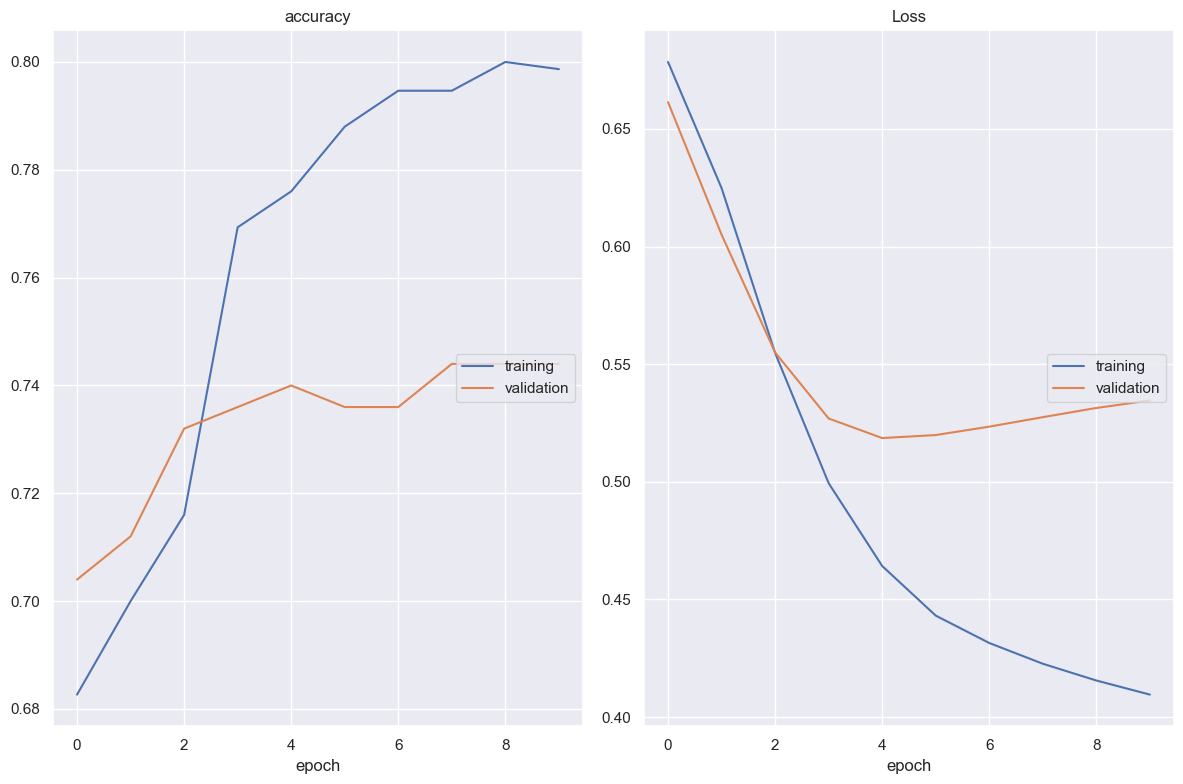

accuracy
	training         	 (min:    0.683, max:    0.800, cur:    0.799)
	validation       	 (min:    0.704, max:    0.744, cur:    0.744)
Loss
	training         	 (min:    0.410, max:    0.678, cur:    0.410)
	validation       	 (min:    0.519, max:    0.661, cur:    0.535)
eights for First Hidden Layer [[ 2.09546834e-01 -1.66092321e-01  1.20861821e-01  1.78071246e-01
  -2.10843146e-01  1.90367952e-01 -1.24234408e-01 -2.50057936e-01
  -2.71768212e-01  1.78702340e-01]
 [ 1.44467011e-01 -1.50965959e-01  1.03773557e-01  8.70525315e-02
  -1.12335883e-01  1.23267889e-01 -1.02576151e-01 -1.73620388e-01
  -1.57120034e-01  1.55414408e-02]
 [ 2.00092688e-01 -7.48343170e-02  2.03510985e-01  1.98887989e-01
  -7.61894882e-02  1.15025260e-01 -7.06196725e-02 -2.31133867e-02
  -8.43189284e-02  2.23856851e-01]
 [ 1.38271496e-01  8.96293148e-02  1.24062918e-01  1.45576149e-01
   1.06459431e-01  9.67445523e-02  5.42989746e-02  1.27827600e-01
   1.47827893e-01  7.69811049e-02]
 [-8.05881843e-02  1.051

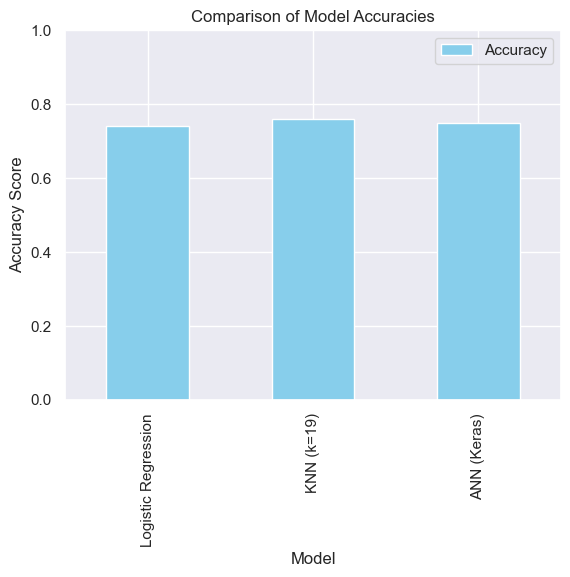

In [ ]:
import keras
from matplotlib import pyplot as plt
import seaborn as sn  # Fix 1: Define the alias 'sn'
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.calibration import LabelEncoder
from sklearn.datasets import fetch_openml
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split

def main():

    dataset = fetch_openml("credit-g")  

    # Step 2: Read the data into a dataframe

    df = dataset.frame
    print("\n---TYPE---")
    print(type(df))
    print("DATAFRAME",df)
    print("DESCRIBE", df.describe())


    # 2. Clean the 'class' column and create 'target_num'
    # We use .str.strip("'") in case the CSV has literal single quotes like 'good'
    df['target_num'] = df['class'].str.strip("'").map({'good': 1, 'bad': 0})

    # --- This line prevents the KeyError ---
    if 'target_num' not in df.columns:
        print("Error: target_num was not created. Check if 'class' column exists!")
    else:
        print("Success: target_num created. Proceeding to plot...")


    # A bar plot shows us the number of items per class label
    plt.figure(figsize=(11,2))
    sn.set(style="darkgrid") # type: ignore
    ax = sn.countplot(x="class", # type: ignore
                    data=df).set_title('Distribution of Credit Risk (Good vs Bad)')

    # sn.heatmap(df.corr(), annot = True) # type: ignore
    # plt.show()

    # 2. Heatmap (Fix 3: corr() only works on numeric columns)
    plt.figure(figsize=(12, 8))
    # Select only numeric columns for the correlation matrix
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    sn.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

    # sn.pairplot(data = df, hue = ("Good")) # type: ignore
    # plt.show()

    # Note: Pairplots can be very slow with many features. 
    # We'll pick a few key numerical columns to visualize.
    sn.pairplot(data=df, vars=['age', 'credit_amount', 'duration'], hue="class")
    plt.show()

    # A scatter plot shows us there is a trend between age affecting credit risk
    # 2. Scatter Plot: Age vs Credit Amount (colored by Credit Risk)
    # This shows if older people take larger loans and if those are risky.
    plt.figure(figsize=(10, 6))
    sn.scatterplot(data=df, x="age", y="credit_amount", hue="class", palette={'good': 'green', 'bad': 'red'}, alpha=0.7)
    plt.title('Trend: Credit Amount and Age by Risk')
    plt.show()

    # 4. Plot the Logistic Regression Curve
    # 'logistic=True' estimates the probability of being in class 1 ('good')
    sn.regplot(x='age', y='target_num', data=df, logistic=True, 
            scatter=False, 
            line_kws={'color': 'blue', 'linewidth': 3, 'label': 'Probability of Good Credit'})

    # 5. Add labels and title
    plt.title('Probability of "Good" Credit based on Age')
    plt.ylabel('Probability (1.0 = Good)')
    plt.xlabel('Age')
    plt.legend()
    plt.show()


    # View a summary of the dataframe - all categorical data
    print("\nView a summary of the dataframe - all categorical data:")
    print(f"View a summary of the dataframe - all categorical data: {df.info()}")

    # check any missing values - if found, drop missing
    missing_values = df.isna()
    print("\nMISSING TRUE/FALSE")
    print(missing_values)
    # Count total missing values per column
    missing_counts = missing_values.sum()
    print("\nCOUNT OF MISSING VALUES PER COLUMN:")
    print(missing_counts)
    print("\n---DATA TYPE---")
    print(type(df))
    print("\n--- DATA FRAME---")
    print(df)
    print(f"Final DataFrame shape before data preprocessing or normalization: {df.shape}")

    # Input and output data
    x_columns = 20
    X = df.iloc[:, 0:x_columns]
    y = df.iloc[:, x_columns]

    print("original X", X)
    print(y)


    # Encoding

    # Target Encoding ---
    # Convert 'class' to 0 and 1
    # Note: LabelEncoder expects a 1D array, which y already is!
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Print to verify: 'bad' usually becomes 0, 'good' becomes 1
    print("Y categorical",y[:10])
    print("Y cencoded",y_encoded[:10])

    # 3. Apply One-Hot Encoding to the features
    # This will turn your 13 'object' columns into many 0/1 columns
    # and keep your 7 'int64' columns as they are.
    X_encoded = pd.get_dummies(X, drop_first=True)
    X_encoded = X_encoded.astype(int) #to avoid True False after encoding
    print(X_encoded)
    # Export to CSV with UTF-8 encoding
    X_encoded.to_csv('output_cc.csv', encoding='utf-8', index=False)


    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded)

    # Check the data was scaled!
    print("Original first row:", X.iloc[0].values)
    print("Scaled first row:", X_scaled[0])

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, 
                                                        y_encoded, 
                                                        test_size = 0.25,
                                                        random_state = 0,
                                                        shuffle = True)

    print(len(X_train), len(y_train), len(X_test), len(y_test))

    # Logistic regression (probabilistic, a parametric model/Equation-Based. This means it assumes the relationship between the input variables ($X$) and the output ($y$) can be described by a fixed set of parameters (weights)
    print("\n--- Logistic regression ---")

    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print("",predictions)
    print(y_test)

    print("Accuracy/Score from Training data ",model.score(X_train,y_train))
    print("Accuracy/Score from Testing data", model.score(X_test,y_test))

    from sklearn.metrics import confusion_matrix
    print(confusion_matrix(y_test, predictions))

    # If you want to be able to access the results, save them to a list:

    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    print("True Positives:",tp)
    print("True Negatives:",tn)
    print("False Negatives:",fn)
    print("False Positives:",fp)

    from sklearn.metrics import classification_report
    print(classification_report(y_test, predictions))

    from sklearn.metrics import precision_score, recall_score, f1_score 
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-score: {f1:.2f}')

    """
    This model has a Model Accuracy of 79%.
    In other words, 79% of all guesses made by this model will be the correct class label.

    We can display this information visually in a Confusion Matrix:
    A Classification Report gives us all the available Classification metrics for each class as well as overall: 
    - Recall (how many actual positives are identified?)
    - Precision (how accurate the positive predictions are.)
    - F1-Score (combine precision and recall to deal with class inbalance)
    - and the overall Model Accuracy (overall proportion of correct predictions).

    #### The evaluation metrics can also be calculated individually using their sklearn methods, instead of just viewing the classification table from sklearn. 

    precision of bad credit is 0.56 - not good

    0.7946666666666666
    0.736
    [[ 38  36]
    [ 30 146]]
    True Positives: 146
    True Negatives: 38
    False Negatives: 30
    False Positives: 36
                precision    recall  f1-score   support

            0       0.56      0.51      0.54        74
            1       0.80      0.83      0.82       176

        accuracy                           0.74       250
    macro avg       0.68      0.67      0.68       250
    weighted avg       0.73      0.74      0.73       250

    Precision: 0.80
    Recall: 0.83
    F1-score: 0.82

    """


    # KNN
    print("\n--- K nearest neighbour KNN ---")

    from sklearn.neighbors import KNeighborsClassifier

    model_knn = KNeighborsClassifier(n_neighbors = 5)

    model_knn.fit(X_train, y_train)

    print("Actual first value in KNN test data for X features ",X_test[:1])
    print("Predicted first value using KNN test data for X fearures ",model_knn.predict(X_test[:1]))

    predictions_knn = model_knn.predict(X_test) #y_test is our knowns!

    print("predictions..",predictions_knn)


    from sklearn.metrics import classification_report, confusion_matrix

    print(confusion_matrix(y_true = y_test,
                        y_pred = predictions_knn))

    sn.heatmap(confusion_matrix(y_test,predictions_knn), annot = True).set_title("Credit risk Heat Map")
    plt.show()

    true_neg, false_pos, false_neg, true_pos = confusion_matrix(y_test, predictions_knn).ravel()

    print("True Positives:",true_pos)
    print("True Negatives:", true_neg)

    # Calculate the accuracy of the model on the training data and the testing data. How does the performance compare?
    print("Training Accuracy:", round(model_knn.score(X_train, y_train), 2))
    print("Testing Accuracy:",  round(model_knn.score(X_test, y_test), 2))

    print("Training Accuracy---:", model_knn.score(X_train, y_train))
    print("Testing Accuracy----:",  model_knn.score(X_test, y_test))


    print(classification_report(y_test,predictions_knn))

    # Make a loop to run a range of nearest neighbours to find the best model

    # Initialize lists to store metrics
    err_rate = []
    accuracy = []


    #  Calculate multiple models:
    # Test k from 1 up to 100
    print("Starting hyperparameter tuning for K...")
    for i in range(1,101):
        knn = KNeighborsClassifier(n_neighbors = i)
        knn.fit(X_train, y_train)
        # Make predictions on the VALIDATION set
        predictions_i = knn.predict(X_test)

        # and Track the results!
        # Calculate the error rate: (Number of incorrect predictions) / (Total predictions)
        err_rate.append(np.mean(predictions_i != y_test)) # another way to calculate the error rate
        accuracy.append(knn.score(X_test, y_test))

        
    # --- Find the Best K using the requested list methods ---

    # Find the minimum error rate value
    min_error = min(err_rate)
    # Find the index of that minimum error
    best_err_index = err_rate.index(min_error)
    # Calculate the actual K value (Index + 1, since the loop started at K=1)
    best_k = best_err_index + 1 

    # Run the best model

    best_knn_model = KNeighborsClassifier(n_neighbors = best_k)
    best_knn_model.fit(X_train, y_train)


    print(best_knn_model.score(X_test, y_test))

    print("\n--- Tuning Results Summary ---")
    print(f"Optimal k found (lowest error): {best_k}")
    print(f"Lowest Validation Error Rate: {min_error:.4f}")
    print(f"Highest Validation Accuracy at k={best_k}: {accuracy[best_err_index]:.4f}")


    # --- Final Model Training and Evaluation on TEST SET ---

    # 1. Train the final model using the BEST k on the full Training Set
    print(f"\nTraining final model with Optimal k = {best_k}...")
    best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
    best_knn_model.fit(X_train, y_train)

    # 2. Evaluate the final model on the independent TEST SET
    final_predictions = best_knn_model.predict(X_test)

    # --- Classification Metrics ---

    # Final Accuracy Score
    final_accuracy = accuracy_score(y_test, final_predictions)
    print("best accuracy", best_knn_model.score(X_test, y_test))
    # final_accuracy = best_knn_model.score(X_test, y_test)
    print(f"\nFinal Test Set Accuracy (k={best_k}): {final_accuracy:.4f}")

    # Final Confusion Matrix
    final_conf_matrix = confusion_matrix(y_true=y_test, y_pred=final_predictions)
    print("\nFinal Confusion Matrix (Test Set):")
    print(final_conf_matrix)

    # ANN
    print("\n--- Artificial Neural Network ANN ---")

    from keras.models import Sequential
    model = Sequential()
    from keras.layers import Input, Dense

    # 1. Get the number of features automatically
    n_features = X_train.shape[1] 
    print(f"Feeding {n_features} features into the model.")

    # input_layer = Input(shape=(11,)) #Optional
    input_layer = Input(shape=(n_features,)) #Optional

    hidden_layer_1 = Dense(units = 6, activation='relu', kernel_initializer='uniform') #n hidden layer(s) required

    output_layer = Dense(units = 1, activation='sigmoid', kernel_initializer='uniform') #required


    model.add(input_layer) #Optional
    model.add(hidden_layer_1)
    model.add(output_layer)

    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    model.fit(X_train, y_train, 
            batch_size = 10,
            epochs = 9)

    print("\n--- Artificial Neural Network ANN model summary---")
    model.summary()

    # .predict() calculates the probability of a new point belonging to the class 'good' credit (or 1) category
    y_pred = model.predict(X_test)
    y_pred[0:6]

    # We convert this to binary to create a confusion matrix since 
    # it won't be meaningful on the probabilities

    y_pred = (y_pred > 0.5)
    y_pred[0:6]

    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import confusion_matrix,classification_report
    confusion_matrix = confusion_matrix(y_test, y_pred)

    print("\n--- Confusion Matrix ---")
    print("Confusion Matrix", confusion_matrix)
    print("\n--- Classification Report ---")
    print("classification report", classification_report(y_test,y_pred))


    from livelossplot import PlotLossesKeras

    # Define a sequential model
    from keras.models import Sequential
    model = Sequential()

    # Add the layers and nodes
    input_layer = Input(shape=(n_features,))
    model.add(input_layer)

    hidden_layer = Dense(units=10, activation='relu', kernel_initializer='uniform')
    model.add(hidden_layer)

    output_layer = Dense(units=1, activation='sigmoid', kernel_initializer='uniform')
    model.add(output_layer)

    # Compile the model
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    # Add early stopping
    callbacks = keras.callbacks.EarlyStopping(monitor='val_loss',
                                min_delta=0.0001,
                                patience = 10,
                                verbose=0, mode='auto')

    #Train the model
    model.fit(X_train, y_train,
            batch_size = 10,
            epochs = 20,
            validation_data=(X_test, y_test),
            callbacks=[PlotLossesKeras(),callbacks],
            verbose=0)

    # Weights for First Hidden Layer
    weights = model.layers[0].get_weights()[0]  #Remove final [0] to get all model weights at once
    print("eights for First Hidden Layer", weights)

    # Biases for First Hidden Layer
    biases = model.layers[0].get_weights()[1]
    print("Biases for First Hidden Layer",biases)

    # Weights for Output Layer
    weights = model.layers[1].get_weights()[0]
    print("Weights for Output Layer", weights)


    # Weights for Output Layer
    biases = model.layers[1].get_weights()[1]
    print("Weights for Output Layer", biases)

    # --- FINAL SUMMARY TABLE ---
    results = {
        'Model': ['Logistic Regression', 'KNN (k=19)', 'ANN (Keras)'],
        'Accuracy': [0.74, 0.76, 0.75],
        'Precision (Class 1)': [0.80, 0.77, 0.83],
        'Recall (Class 0)': [0.51, 0.34, 0.59]
    }

    df_results = pd.DataFrame(results)
    print("\n=== FINAL MODEL COMPARISON ===")
    print(df_results)

    # Optional: Visualization of the comparison
    df_results.plot(kind='bar', x='Model', y='Accuracy', ylim=(0, 1), color='skyblue')
    plt.title('Comparison of Model Accuracies')
    plt.ylabel('Accuracy Score')
    plt.show()


main()